# Setup Path

In [ ]:
import os
import sys

ROOT = os.path.abspath("..")
print(f"path root: {ROOT}")

path root: c:\Users\Cerdas05\Skripshot\U-Net-Architecture


# Import Library

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATASET_DIR = os.path.join(ROOT, "dataset")
splits = ['training', 'testing', 'validation']
print(f'dataset dir: {DATASET_DIR}')

dataset dir: c:\Users\Cerdas05\Skripshot\U-Net-Architecture\dataset


# Jumlah dan distribusi data

In [ ]:
data_count = {}

for split in splits:
    images = Path(DATASET_DIR) / split / 'images'
    masks = Path(DATASET_DIR) / split / 'masks'

    n_images = len(list(images.glob("*"))) if images.exists() else 0
    n_masks = len(list(masks.glob("*"))) if masks.exists() else 0

    data_count[split] = {
        'gambar': n_images,
        'mask': n_masks,
        'Cocok'  : '✅' if n_images == n_masks else '❌'
    }

df_count = pd.DataFrame(data_count).T
df_count.index_name = 'split'

print('\n── Distribusi Jumlah Data ──')
print(df_count.to_string())
print(f'\nTotal gambar: {df_count["gambar"].sum()}')



── Distribusi Jumlah Data ──
           gambar  mask Cocok
training     2595  2595     ✅
testing      1001  1001     ✅
validation    101   101     ✅

Total gambar: 3697


# Distribusi ukuran gambar

In [ ]:
img_dir = Path(DATASET_DIR) / 'training' / 'images'
img_paths = sorted(list(img_dir.glob("*.*")))
heights, widths, aspects = [], [], []

for img_path in tqdm(img_paths, desc="membaca distribusi ukuran gambar"):
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)
        aspects.append(w / h)

print(f"\n-- Statistik Ukuran Gambar (Training)")
print(f"Tinggi -> min: {min(heights)} | max: {max(heights)} | rata-rata: {np.mean(heights):.0f}")
print(f"Lebar -> min: {min(widths)} | max: {max(widths)} | rata-rata: {np.mean(widths):.0f}")

membaca distribusi ukuran gambar:   0%|          | 0/2595 [00:00<?, ?it/s]


-- Statistik Ukuran Gambar (Training)
Tinggi -> min: 540 | max: 4499 | rata-rata: 2167
Lebar -> min: 576 | max: 6748 | rata-rata: 3188


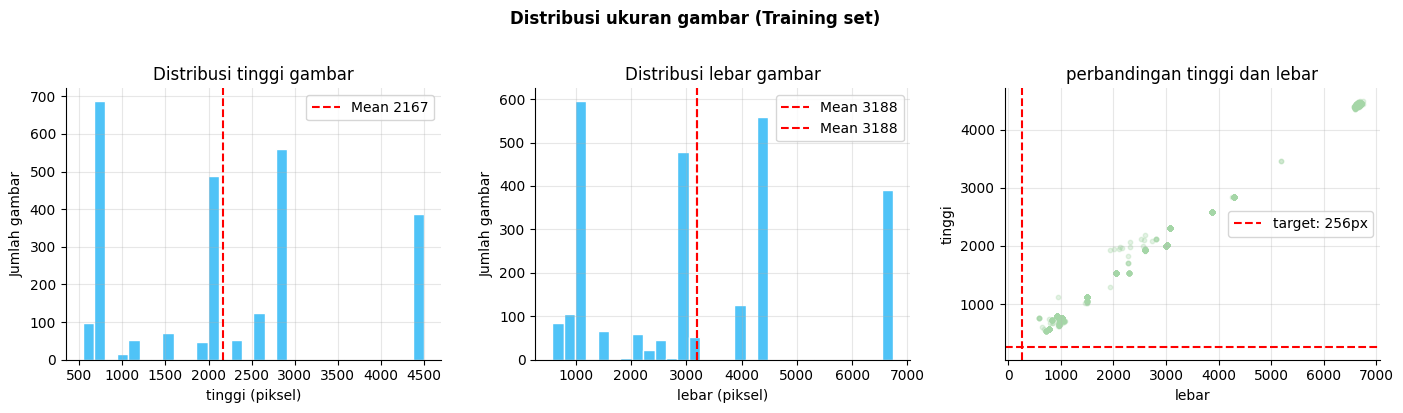

In [ ]:
# plot hasil distribusi gambar
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribusi ukuran gambar (Training set)', fontweight='bold', y=1.02)

axs[0].hist(heights, bins=30, color='#4FC3F7', edgecolor='white')
axs[0].axvline(np.mean(heights), color='red', linestyle='--', linewidth=1.5, label=f'Mean {np.mean(heights):.0f}')
axs[0].set_title('Distribusi tinggi gambar')
axs[0].set_xlabel('tinggi (piksel)')
axs[0].set_ylabel('Jumlah gambar')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].hist(widths, bins=30, color='#4FC3F7', edgecolor='white')
axs[1].axvline(np.mean(widths), color='red', linestyle='--', linewidth=1.5, label=f'Mean {np.mean(widths):.0f}')
axs[1].set_title('Distribusi lebar gambar')
axs[1].set_xlabel('lebar (piksel)')
axs[1].set_ylabel('Jumlah gambar')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[1].hist(widths, bins=30, color='#4FC3F7', edgecolor='white')
axs[1].axvline(np.mean(widths), color='red', linestyle='--', linewidth=1.5, label=f'Mean {np.mean(widths):.0f}')
axs[1].set_title('Distribusi lebar gambar')
axs[1].set_xlabel('lebar (piksel)')
axs[1].set_ylabel('Jumlah gambar')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[2].scatter(widths, heights, alpha=0.3, s=10, color='#A5D6A7')
axs[2].axvline(256, color='red', linestyle='--', linewidth=1.5)
axs[2].axhline(256, color='red', linestyle='--', linewidth=1.5, label='target: 256px')
axs[2].set_title('perbandingan tinggi dan lebar')
axs[2].set_xlabel('lebar')
axs[2].set_ylabel('tinggi')
axs[2].legend()
axs[2].grid(alpha=0.3)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'output/eda/ukuran_distribusi.png'), dpi=150, bbox_inches='tight')
plt.show()

# Distribusi area lesi

In [ ]:
mask_dir = Path(DATASET_DIR) / 'training' / 'masks'
mask_paths = sorted(list(mask_dir.glob('*.png')))

lesi_ratios = []
for mask_path in tqdm(mask_paths, desc='membaca area lesi (mask training)'):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is not None:
        total = mask.size
        lesi = (mask > 127).sum()
        lesi_ratios.append((lesi / total) * 100)

lesi_ratios = np.array(lesi_ratios)

print(f'\n── Statistik Area Lesi ──')
print(f'Rata-rata  : {np.mean(lesi_ratios):.2f}%')
print(f'Median     : {np.median(lesi_ratios):.2f}%')
print(f'Minimum    : {np.min(lesi_ratios):.2f}%')
print(f'Maximum    : {np.max(lesi_ratios):.2f}%')
print(f'Std        : {np.std(lesi_ratios):.2f}%')


membaca area lesi (mask training):   0%|          | 0/2594 [00:00<?, ?it/s]


── Statistik Area Lesi ──
Rata-rata  : 21.40%
Median     : 13.81%
Minimum    : 0.30%
Maximum    : 98.66%
Std        : 20.83%


# Deteksi gambar berambut

In [ ]:
def has_hair(img_path: str, threshold: int = 500) -> bool:
    img = cv2.imread(img_path)

    if img is None:
        return
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(17, 17))
    bh = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(bh, 10, 255, cv2.THRESH_BINARY)

    return int(mask.sum() // 255) > threshold

hair_stats = {}

for split in splits:
    imgs_dir = Path(DATASET_DIR) / split / 'images'

    with_hair = 0
    without_hair = 0

    for img_dir in tqdm(imgs_dir, desc=f"mendeteksi rambut di dataset {split}"):
        if has_hair(img_dir):
            with_hair += 1
        else:
            without_hair += 1

    total = with_hair + without_hair

    hair_stats[split] = {
        'Total'         : total,
        'Ada Rambut'    : with_hair,
        'Tidak Ada'     : without_hair,
        '% Ada Rambut'  : f'{with_hair/total*100:.1f}%' if total > 0 else '0%',
        '% Tidak Ada'   : f'{without_hair/total*100:.1f}%' if total > 0 else '0%'
    }

df_hair = pd.DataFrame(hair_stats).T
df_hair.index.name = 'Split'
print('\n── Hasil Deteksi Gambar Berambut ──')
print(df_hair.to_string())
    

# Visualisasi sampel gambar dan mask